# A5 — Brushstroke Geometric Features

**Goal:** Extract individual brushstroke paths and compute their geometric statistics. Visualise length, width, curvature, and orientation distributions for Manet vs a contemporary.

**Key paper:** Li, Yao, Hendriks & Wang (2012), *IEEE T-PAMI* 34(6):1159–1176 — rhythmic brushstrokes, van Gogh

**Key question for Manet:** Can individual brushstrokes be reliably extracted from Manet's flat-colour, contour-dominated style? Or does the flat-area segmentation break the method?

---

### Mathematics

**Extraction pipeline:**
1. Canny edge detection → binary edge map
2. Morphological skeletonisation → 1-pixel-wide paths
3. Connected component labelling → individual brushstroke regions
4. Per-brushstroke feature extraction

**Per-brushstroke descriptors:**
- **Length** $L$: arc length along skeletonised path
- **Width** $W$: mean perpendicular cross-section width
- **Aspect ratio** $AR = L / W$
- **Curvature** $\kappa = \frac{|y''|}{(1 + y'^2)^{3/2}}$ (mean absolute curvature)
- **Orientation** $\theta$: dominant angle from structure tensor

**Expected for Manet:** Long $L$, low $\kappa$ (flat colour areas with strong confident contours)  
**Expected for da Vinci (sfumato):** Short $L$, high $\kappa$, dense packing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from utils import load_image, to_gray, show_pair
from skimage.feature import canny
from skimage.morphology import skeletonize, label, remove_small_objects
from skimage.measure import regionprops
from scipy.ndimage import gaussian_filter

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

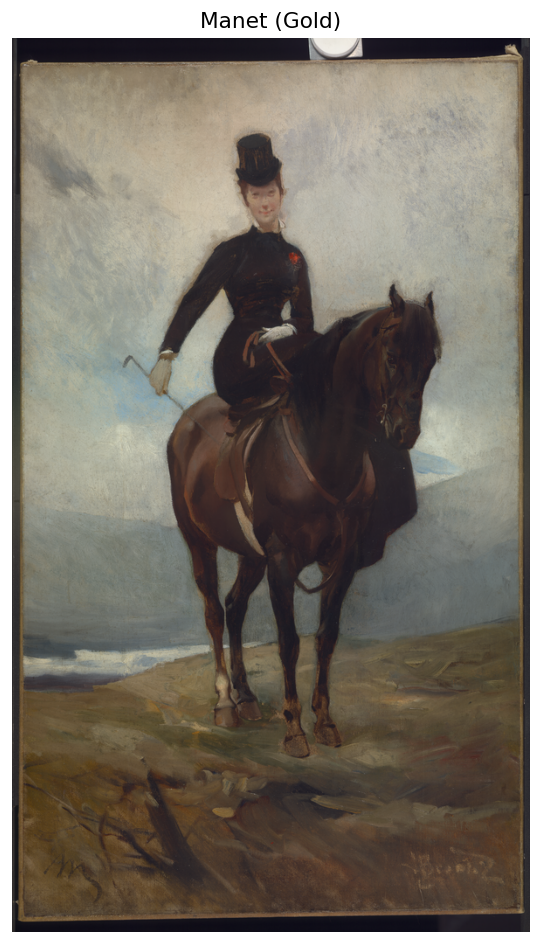

In [5]:
# ── Configuration ─────────────────────────────────────────────────────────────
PATH_MANET     = Path('Manet(Gold).tif')
CANNY_SIGMA    = 2.0    # Gaussian smoothing before edge detection
CANNY_LOW      = 0.05   # Low hysteresis threshold
CANNY_HIGH     = 0.15   # High hysteresis threshold
MIN_STROKE_LEN = 10     # Minimum brushstroke length in pixels
# ─────────────────────────────────────────────────────────────────────────────

img_m  = load_image(PATH_MANET)
img_m  = np.rot90(img_m, k=1)  # Rotate counterclockwise 90 degrees
gray_m = to_gray(img_m)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img_m)
ax.set_title('Manet (Gold)', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## 1. Edge Detection → Skeletonisation → Brushstroke Regions

In [6]:
def extract_strokes(gray: np.ndarray,
                    sigma: float = 2.0,
                    low: float = 0.05, high: float = 0.15,
                    min_len: int = 10) -> tuple:
    """
    Returns (edge_map, skeleton, labelled_skeleton, n_strokes).
    """
    # Step 1: Canny edges
    edges = canny(gray, sigma=sigma, low_threshold=low, high_threshold=high)

    # Step 2: Skeletonise — thin edges to 1-pixel paths
    skeleton = skeletonize(edges)

    # Step 3: Remove very short strokes (noise)
    labelled = label(skeleton)
    cleaned  = remove_small_objects(labelled, min_size=min_len)
    labelled_clean = label(cleaned > 0)
    n = labelled_clean.max()

    return edges, skeleton, labelled_clean, n


edges_m, skel_m, lab_m, n_m = extract_strokes(
    gray_m, CANNY_SIGMA, CANNY_LOW, CANNY_HIGH, MIN_STROKE_LEN)

print(f'Manet: {n_m} brushstroke segments extracted')

Manet: 125 brushstroke segments extracted


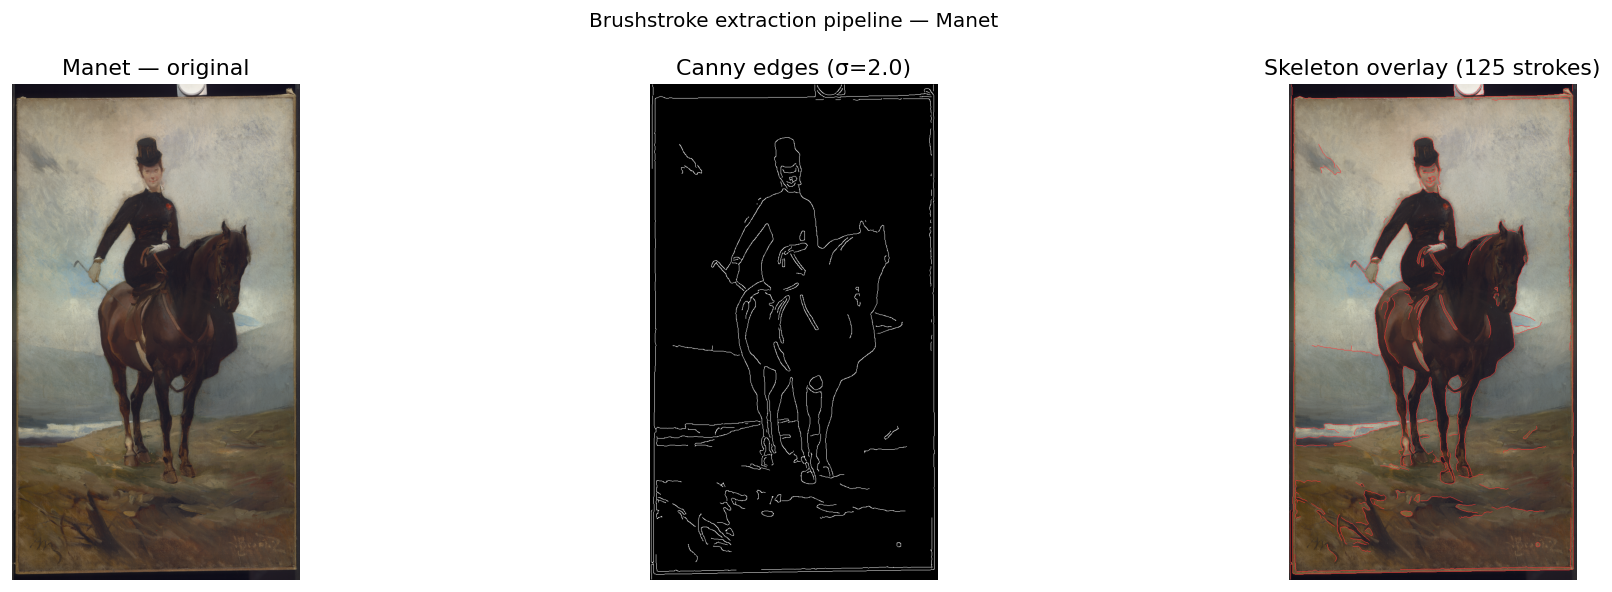

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Brushstroke extraction pipeline — Manet', fontsize=12)

axes[0].imshow(img_m)
axes[0].set_title('Manet — original')
axes[0].axis('off')

axes[1].imshow(edges_m, cmap='gray')
axes[1].set_title(f'Canny edges (σ={CANNY_SIGMA})')
axes[1].axis('off')

# Overlay skeleton on original
overlay = img_m.copy()
overlay[skel_m > 0] = [1.0, 0.2, 0.2]   # Red skeleton
axes[2].imshow(overlay)
axes[2].set_title(f'Skeleton overlay ({lab_m.max()} strokes)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

---
## 2. Per-Brushstroke Feature Extraction

In [8]:
def compute_curvature(coords: np.ndarray) -> float:
    """
    Mean absolute curvature κ = |y''| / (1 + y'²)^{3/2}
    along a sequence of (row, col) coordinates.
    Returns 0 if fewer than 3 points.
    """
    if len(coords) < 3:
        return 0.0
    y, x = coords[:, 0].astype(float), coords[:, 1].astype(float)
    # Parameterise by arc length
    dx = np.gradient(x)
    dy = np.gradient(y)
    d2x = np.gradient(dx)
    d2y = np.gradient(dy)
    denom = (dx**2 + dy**2)**1.5 + 1e-9
    kappa = np.abs(dx * d2y - dy * d2x) / denom
    return float(kappa.mean())


def extract_stroke_features(labelled: np.ndarray) -> dict:
    """
    Extract geometric features from all brushstroke regions.
    Returns dict of lists: L, W, AR, kappa, theta.
    """
    props_list = regionprops(labelled)
    L_list, W_list, AR_list, kappa_list, theta_list = [], [], [], [], []

    for prop in props_list:
        # Arc length ≈ number of pixels in skeletonised region
        L = prop.area
        # Width from bounding box minor axis
        W = max(prop.minor_axis_length, 1.0)
        AR = L / W

        # Orientation from region's major axis (in radians)
        theta = prop.orientation  # [-π/2, π/2]

        # Curvature: get pixel coordinates of the region
        coords = prop.coords  # (n_pixels, 2)
        # Sort by arc order (approximate: sort by position along major axis)
        proj_axis = coords[:, 0] * np.cos(theta) + coords[:, 1] * np.sin(theta)
        sort_idx  = np.argsort(proj_axis)
        kappa = compute_curvature(coords[sort_idx])

        L_list.append(L)
        W_list.append(W)
        AR_list.append(AR)
        kappa_list.append(kappa)
        theta_list.append(theta)

    return {'L': np.array(L_list), 'W': np.array(W_list), 'AR': np.array(AR_list),
            'kappa': np.array(kappa_list), 'theta': np.array(theta_list)}


strokes_m = extract_stroke_features(lab_m)
print(f'Manet: {len(strokes_m["L"])} strokes  |  mean L={strokes_m["L"].mean():.1f}px  mean κ={strokes_m["kappa"].mean():.4f}')

Manet: 125 strokes  |  mean L=103.2px  mean κ=0.4125


---
## 3. Distribution Plots — L, W, AR, κ, θ

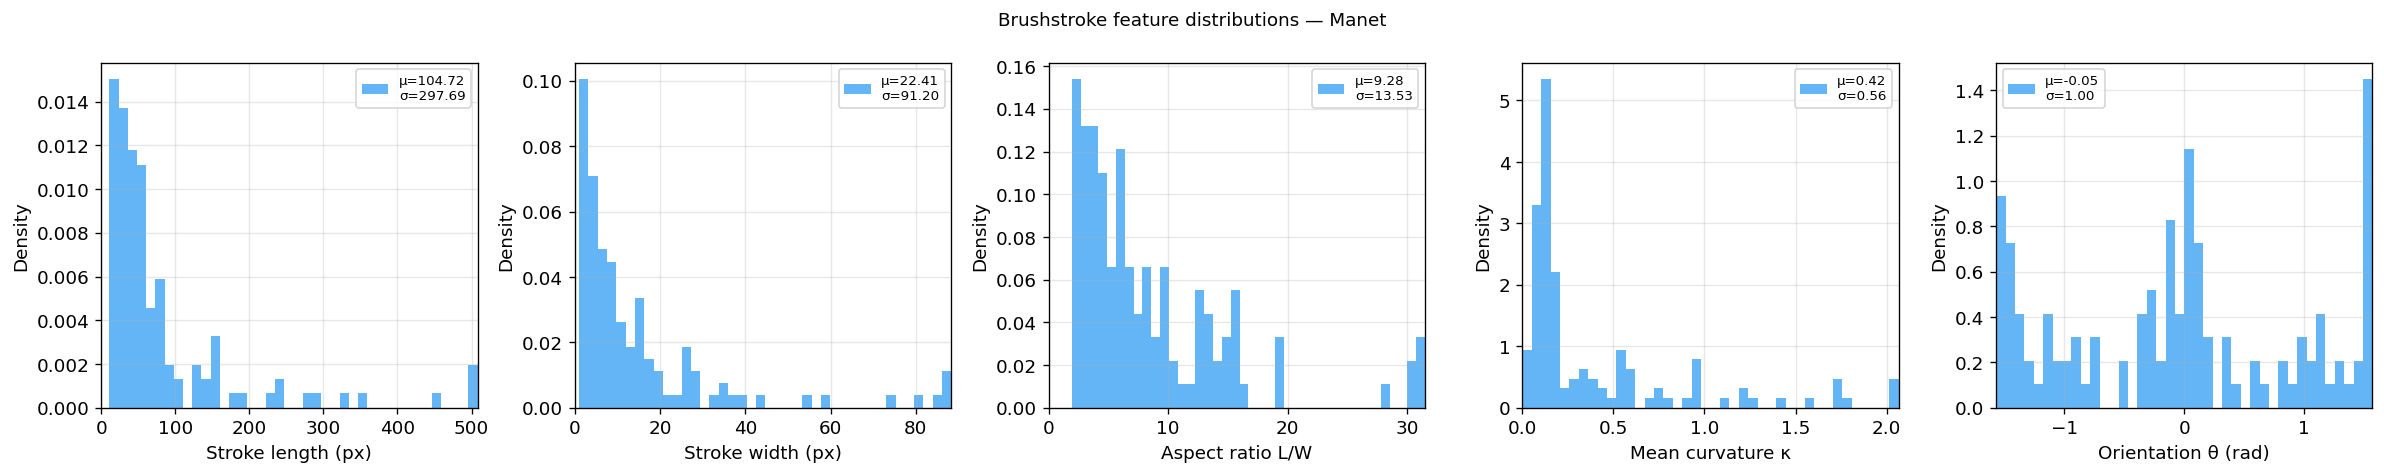

In [8]:
features_to_plot = [
    ('L',     'Stroke length (px)',   (0, np.percentile(strokes_m['L'], 98))),
    ('W',     'Stroke width (px)',    (0, np.percentile(strokes_m['W'], 98))),
    ('AR',    'Aspect ratio L/W',     (0, np.percentile(strokes_m['AR'], 98))),
    ('kappa', 'Mean curvature κ',     (0, np.percentile(strokes_m['kappa'], 98))),
    ('theta', 'Orientation θ (rad)',  (-np.pi/2, np.pi/2)),
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Brushstroke feature distributions — Manet', fontsize=11)

for ax, (feat, xlabel, xlim) in zip(axes, features_to_plot):
    data_m = strokes_m[feat]
    data_m_c = np.clip(data_m, xlim[0], xlim[1])

    ax.hist(data_m_c, bins=40, density=True, alpha=0.7, color='#2196F3',
            label=f'μ={data_m.mean():.2f}\nσ={data_m.std():.2f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.set_xlim(xlim)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. Curvature Heatmap

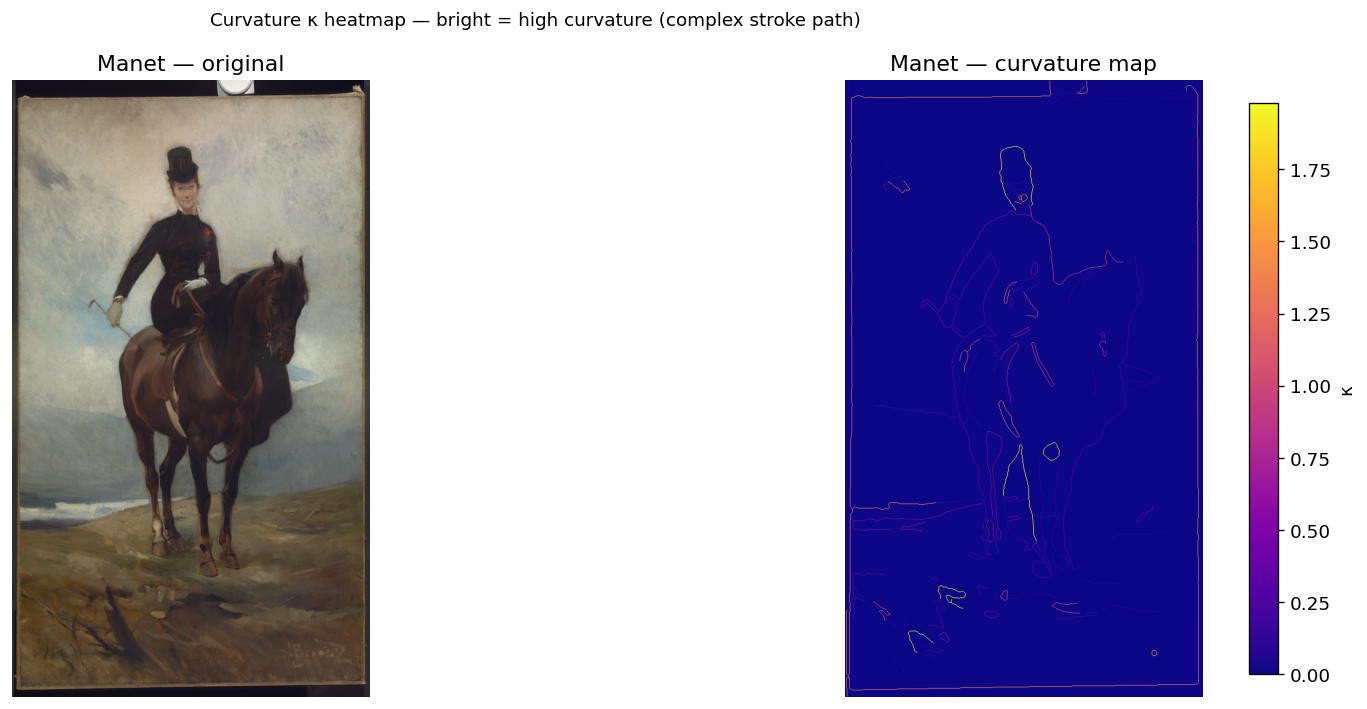

In [9]:
def curvature_heatmap(labelled: np.ndarray, stroke_feats: dict) -> np.ndarray:
    """Paint κ value of each stroke region onto a spatial map."""
    heat = np.zeros(labelled.shape)
    props = regionprops(labelled)
    for i, prop in enumerate(props):
        if i < len(stroke_feats['kappa']):
            coords = prop.coords
            heat[coords[:, 0], coords[:, 1]] = stroke_feats['kappa'][i]
    return heat


heat_m = curvature_heatmap(lab_m, strokes_m)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Curvature κ heatmap — bright = high curvature (complex stroke path)', fontsize=11)

vmax = np.percentile(heat_m[heat_m > 0], 95) if (heat_m > 0).any() else 1

axes[0].imshow(img_m)
axes[0].set_title('Manet — original')
axes[0].axis('off')

im = axes[1].imshow(heat_m, cmap='plasma', vmin=0, vmax=vmax)
plt.colorbar(im, ax=axes[1], fraction=0.03, label='κ')
axes[1].set_title('Manet — curvature map')
axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## 5. Summary Feature Vector

In [10]:
def stroke_feature_vector(stroke_feats: dict) -> dict:
    """Statistical moments of brushstroke distributions → ~20 features."""
    result = {}
    for key in ['L', 'W', 'AR', 'kappa', 'theta']:
        data = stroke_feats[key]
        result[f'{key}_mean'] = data.mean()
        result[f'{key}_std']  = data.std()
        result[f'{key}_skew'] = float(np.mean(((data - data.mean()) / (data.std() + 1e-9))**3))
        result[f'{key}_kurt'] = float(np.mean(((data - data.mean()) / (data.std() + 1e-9))**4))
    result['n_strokes'] = len(stroke_feats['L'])
    return result


import pandas as pd
fv_m = stroke_feature_vector(strokes_m)

df = pd.DataFrame({'Manet': fv_m})
print('Manet Brushstroke Feature Summary:')
print(df.round(4).to_string())

Manet Brushstroke Feature Summary:
               Manet
L_mean      103.2000
L_std       295.6753
L_skew        9.3292
L_kurt       97.0460
W_mean       22.0537
W_std        90.5163
W_skew       10.3531
W_kurt      112.6427
AR_mean       9.3025
AR_std       13.4685
AR_skew       7.6055
AR_kurt      72.9597
kappa_mean    0.4125
kappa_std     0.5890
kappa_skew    2.8321
kappa_kurt   12.1568
theta_mean    0.0024
theta_std     0.9538
theta_skew   -0.0830
theta_kurt    2.0415
n_strokes   125.0000


---
## 6. Key Observations

| Question | Observation |
|---|---|
| Were brushstrokes reliably extracted, or is segmentation noisy? | |
| What is the typical stroke length L for Manet? | |
| What is the curvature κ distribution — flat or curved strokes? | |
| Are there orientation preferences (θ distribution)? | |
| Do flat-colour areas cause under-extraction of brushstrokes? | |
| Would this method benefit from comparison with another artist? | |